# Antibiotic Susceptibility Testing (Kirby-Bauer Disk Diffusion)

**Objective:** Classify bacterial isolates as Susceptible, Intermediate, or
Resistant to a panel of antibiotics based on measured zone-of-inhibition
diameters.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/zone_measurements.csv")
df

,isolate_id,antibiotic,zone_mm
0,Isolate_1,Ampicillin,8
1,Isolate_1,Ciprofloxacin,24
2,Isolate_1,Gentamicin,16
3,Isolate_1,Tetracycline,20
4,Isolate_2,Ampicillin,19
5,Isolate_2,Ciprofloxacin,14
6,Isolate_2,Gentamicin,13
7,Isolate_2,Tetracycline,12
8,Isolate_3,Ampicillin,15
9,Isolate_3,Ciprofloxacin,18


## Apply breakpoint table

In [2]:
BREAKPOINTS = {
    "Ampicillin": (13, 16),
    "Ciprofloxacin": (15, 20),
    "Gentamicin": (12, 14),
    "Tetracycline": (14, 18),
}

def classify(row):
    r_max, i_max = BREAKPOINTS[row.antibiotic]
    if row.zone_mm <= r_max:
        return "Resistant"
    elif row.zone_mm <= i_max:
        return "Intermediate"
    return "Susceptible"

df["classification"] = df.apply(classify, axis=1)
df

,isolate_id,antibiotic,zone_mm,classification
0,Isolate_1,Ampicillin,8,Resistant
1,Isolate_1,Ciprofloxacin,24,Susceptible
2,Isolate_1,Gentamicin,16,Susceptible
3,Isolate_1,Tetracycline,20,Susceptible
4,Isolate_2,Ampicillin,19,Susceptible
5,Isolate_2,Ciprofloxacin,14,Resistant
6,Isolate_2,Gentamicin,13,Intermediate
7,Isolate_2,Tetracycline,12,Resistant
8,Isolate_3,Ampicillin,15,Intermediate
9,Isolate_3,Ciprofloxacin,18,Intermediate


## Visualise zone diameters by isolate and antibiotic

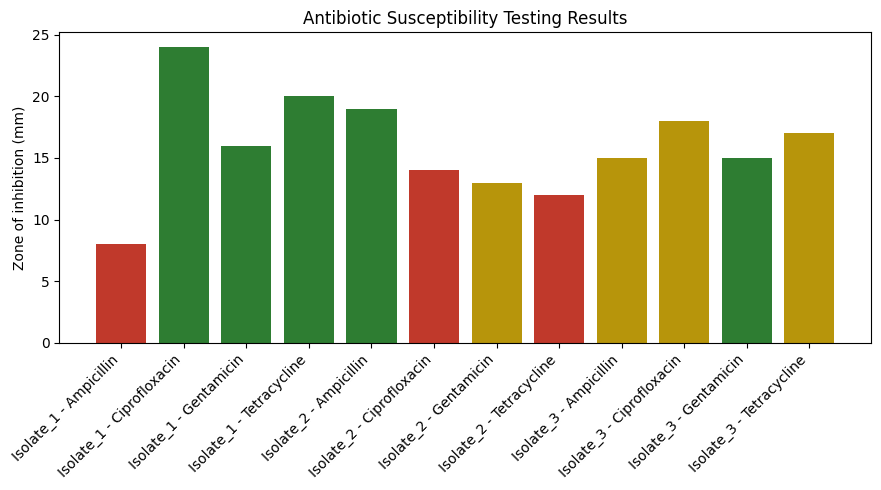

In [3]:
color_map = {"Resistant": "#C0392B", "Intermediate": "#B7950B", "Susceptible": "#2E7D32"}
colors = df.classification.map(color_map)

fig, ax = plt.subplots(figsize=(9, 5))
labels = df.isolate_id + " - " + df.antibiotic
ax.bar(labels, df.zone_mm, color=colors)
ax.set_ylabel("Zone of inhibition (mm)")
ax.set_title("Antibiotic Susceptibility Testing Results")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ast_results_plot.png", dpi=150)
plt.show()

## Summary counts

In [4]:
df.classification.value_counts()

classification
Susceptible     5
Intermediate    4
Resistant       3
Name: count, dtype: int64